# DataDriven_Soccer_Scouting

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras import layers, models
import time

import warnings
warnings.filterwarnings("ignore")



start_time = time.time()

## Introduction and EDA

In [30]:
df = pd.read_csv("merged_data.csv")
# Convert 'season' to a more readable format (e.g., '2020 - 2021')
df['season'] = df['season'].astype(str).str.zfill(4)
df['season'] = "20" + df['season'].str[:2] + " - 20" + df['season'].str[2:]

display(df.head())
print('\nRows: {}, Columns: {}'.format(df.shape[0], df.shape[1]))

,league,season,team,player,nation,pos,age,born,Playing Time_MP,Playing Time_Starts,...,Touches_Att 3rd,Touches_Att Pen,Touches_Def 3rd,Touches_Def Pen,Touches_Live,Touches_Mid 3rd,Touches_Touches,Height,Weight,Preferred foot
0,ENG-Premier League,2024 - 2025,Arsenal,Ben White,ENG,DF,26,1997,17,13,...,238,28,214,55,813,367,813,NaN,NaN,NaN
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,"FW,MF",22,2001,25,20,...,715,162,57,6,978,216,979,178.0,65.0,Left
2,ENG-Premier League,2024 - 2025,Arsenal,David Raya,ESP,GK,28,1995,38,38,...,0,0,1388,880,1480,92,1480,183.0,75.0,Right
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,MF,25,1999,35,33,...,733,81,325,82,1948,909,1948,185.0,80.0,Right
4,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Magalhães,BRA,DF,26,1997,28,28,...,225,40,672,189,1873,985,1873,NaN,NaN,NaN



Rows: 4807, Columns: 117


In [31]:
# Removing rows with null values and Goalkeepers (GK)
not_null_df = df.dropna()
not_null_df = not_null_df[not_null_df['pos'] != 'GK']
print('data without null and GKs\n- rows: {} \n- columns: {}'.format(not_null_df.shape[0], not_null_df.shape[1]))
df_backup = df.copy()
df = not_null_df.copy()

data without null and GKs
- rows: 3396 
- columns: 117


In [32]:
# Select all not numeric columns
not_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
display(df[not_numeric_cols].head())

,league,season,team,player,nation,pos,Preferred foot
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,"FW,MF",Left
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,MF,Right
5,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,"FW,MF",Right
6,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,DF,Left
7,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,DF,Right


In [33]:
# Convert 'Preferred foot' to binary: 1 for 'Right', 0 for 'Left'
df['right_foot'] = df['Preferred foot'].map({'Right': 1, 'Left': 0})
df.drop('Preferred foot', axis=1, inplace=True)

# Identify info columns and create a separate DataFrame for them
info_columns = ['league', 'season', 'team', 'player', 'nation', 'pos', 'born', 'age']
df_info = df[[col for col in df.columns if col.lower() in info_columns]].copy()
numeric_features = df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col.lower() not in info_columns]

X = df[features].copy()

print(f"Matrix 'X' shape: {X.shape[0]} players x {X.shape[1]} statistics")

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Matrix 'X' shape: 3396 players x 109 statistics


## Similarity Search

### PCA

In [34]:
# ==========================================
# 1. PCA TRAINING (Dimensionality Reduction)
# ==========================================
print("--- Baseline Model Training: PCA ---")

# Select 10 principal components (usually enough to retain most information)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# Check how much information (variance) is retained after compression
total_variance = sum(pca.explained_variance_ratio_) * 100
print(f"Explained variance with 10 components: {total_variance:.2f}%")

# ==========================================
# 2. LATENT SPACE CREATION
# ==========================================
# Build a DataFrame with the new 10 mathematical coordinates
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_columns)

# Merge coordinates with text info (player, team, role) saved earlier
# Reset index to guarantee alignment
df_info_reset = df_info.reset_index(drop=True)
df_latent = pd.concat([df_info_reset, df_pca], axis=1)

# ==========================================
# 3. SEARCH ENGINE (Similarity Search)
# ==========================================
def find_similar_pca(player_name, latent_df, top_n=5):
    """
    Find the most similar players using cosine similarity on PCA components.
    """
    # Find the player case-insensitively
    player_idx = latent_df[latent_df['player'].str.lower() == player_name.lower()].index

    if len(player_idx) == 0:
        return f"Error: Player '{player_name}' not found in the dataset. Check the spelling."

    # If there are multiple matches, keep the first one
    idx = player_idx[0]
    real_player = latent_df.loc[idx, 'player']
    real_team = latent_df.loc[idx, 'team']
    print(f"\nSearching similar players for: {real_player} ({real_team})")

    # Isolate target player's "DNA" (10D vector)
    player_vector = latent_df.loc[idx, pca_columns].values.reshape(1, -1)

    # Extract all players' vectors
    all_vectors = latent_df[pca_columns].values

    # Compute cosine similarity
    similarity = cosine_similarity(player_vector, all_vectors)[0]

    # Copy dataframe to avoid touching original
    latent_df_temp = latent_df.copy()
    latent_df_temp['Similarity_Score'] = similarity

    # Sort from most similar to least similar
    # Skip first result (same player with score 1.0)
    similar_players = latent_df_temp.sort_values(by='Similarity_Score', ascending=False).iloc[1:top_n+1]

    # Format score as a readable percentage
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    return similar_players[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]

# Example test
target = "Kevin De Bruyne"
results = find_similar_pca(target, df_latent, top_n=5)
display(results)

--- Baseline Model Training: PCA ---
Explained variance with 10 components: 82.22%

Searching similar players for: Kevin De Bruyne (Manchester City)


,player,age,team,pos,league,season,Match %
1994,Jonas Hofmann,31,Leverkusen,MF,GER-Bundesliga,2023 - 2024,94.6%
1365,Kevin De Bruyne,32,Manchester City,MF,ENG-Premier League,2023 - 2024,93.7%
732,Julian Brandt,28,Dortmund,MF,GER-Bundesliga,2024 - 2025,91.2%
3324,Piotr Zieliński,28,Napoli,MF,ITA-Serie A,2022 - 2023,90.9%
1041,Federico Dimarco,26,Inter,"DF,FW",ITA-Serie A,2024 - 2025,89.5%


### Deep Autoencoder

#### Mix ReLU

--- Building Deep Autoencoder (TensorFlow/Keras) ---



Training in progress...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2575
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1613
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1402
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1277
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1163
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1081
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1038
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1004
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0967
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0936
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0912
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0883
Epoch 13/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0864
Epoch 14/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0845
Epoch 15/100
107/1

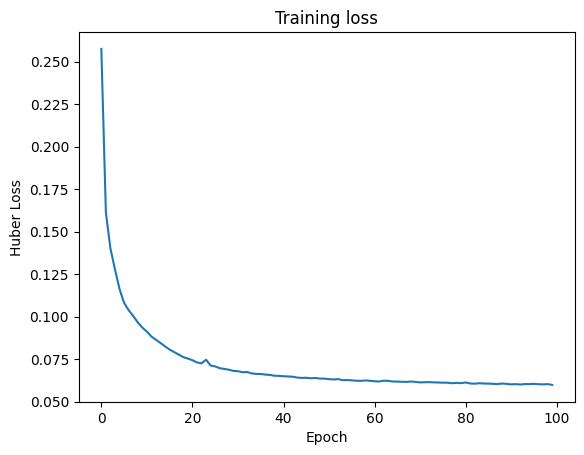


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [35]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU + tanh mix)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of features, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_relu = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_mix_relu = pd.concat([df_info_reset, df_ae_mix_relu], axis=1)

#### Mix Tanh

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.2598
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1570
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1357
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1218
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1126
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1070
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1016
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0971
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0934
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0908
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0883
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0862
Epoch 13/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0843
Epoch 14/100
107/107 ━━━━━━━━━━━━━

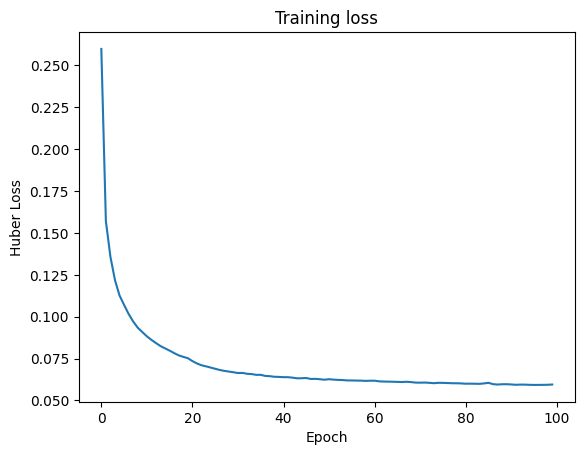


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [36]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU + tanh mix)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of features, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_tanh = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_mix_tanh = pd.concat([df_info_reset, df_ae_mix_tanh], axis=1)

#### Relu

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2572
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1534
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1353
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1251
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1133
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1053
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1002
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0973
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0952
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0933
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0921
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0906
Epoch 13/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0889
Epoch 14/100
107/107 ━━━━━━━━━━━━━

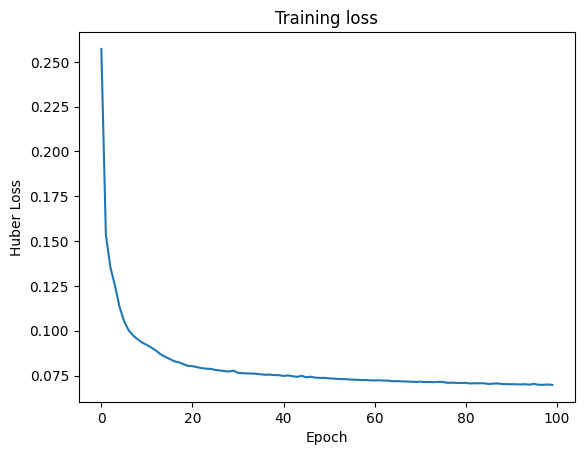


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [37]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_relu = pd.concat([df_info_reset, df_ae_relu], axis=1)

#### Tanh

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2272
Epoch 2/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1517
Epoch 3/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1322
Epoch 4/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1203
Epoch 5/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1117
Epoch 6/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1059
Epoch 7/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1018
Epoch 8/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0978
Epoch 9/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0952
Epoch 10/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0928
Epoch 11/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0911
Epoch 12/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0897
Epoch 13/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0885
Epoch 14/300
107/107 ━━━━━━━━━━━━━

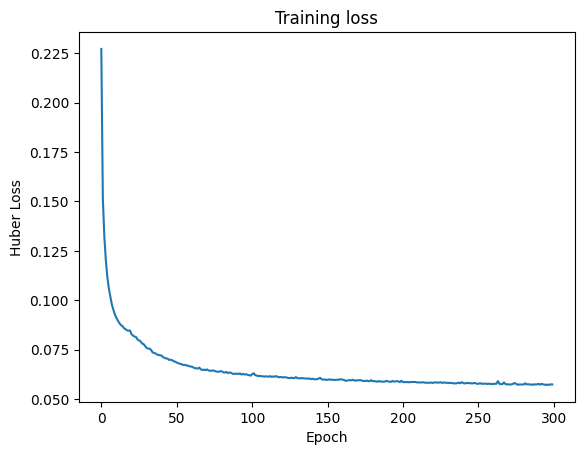


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [38]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (tanh compression)
encoded = layers.Dense(64, activation='tanh')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=300, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
encoder.save("saved_models/encoder_tanh.keras")

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_tanh = pd.concat([df_info_reset, df_ae_tanh], axis=1)

#### ReLU with dropout

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.2642
Epoch 2/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1776
Epoch 3/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1645
Epoch 4/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1578
Epoch 5/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1542
Epoch 6/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1499
Epoch 7/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1456
Epoch 8/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1416
Epoch 9/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1388
Epoch 10/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1359
Epoch 11/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1324
Epoch 12/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1295
Epoch 13/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1271
Epoch 14/500
107/107 ━━━━━━━━━━━━━

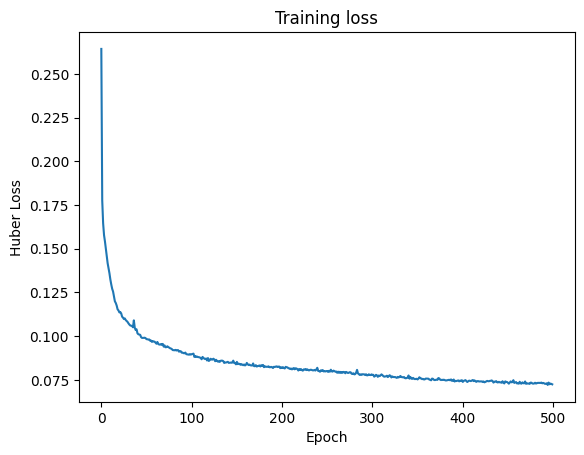


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [39]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='relu')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=500, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_dropout = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_relu_dropout = pd.concat([df_info_reset, df_ae_relu_dropout], axis=1)

#### Tanh with dropout

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 0.2152
Epoch 2/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1535
Epoch 3/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1393
Epoch 4/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1306
Epoch 5/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1258
Epoch 6/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1211
Epoch 7/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1183
Epoch 8/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1160
Epoch 9/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1140
Epoch 10/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.1120
Epoch 11/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1108
Epoch 12/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1102
Epoch 13/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1092
Epoch 14/500
107/107 ━━━━━━━

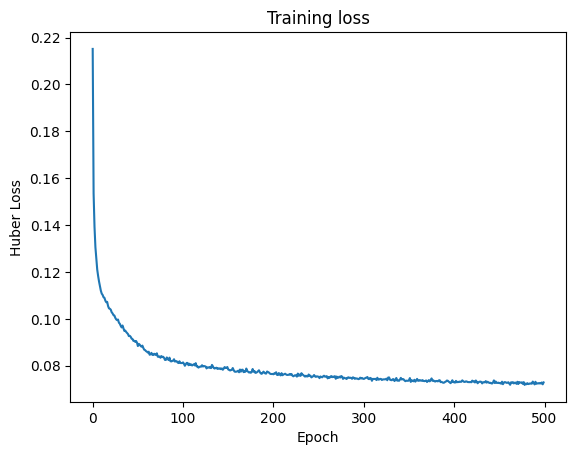


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


In [40]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (tanh compression)
encoded = layers.Dense(128, activation='tanh')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='tanh')(encoded)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='tanh')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=500, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
encoder.save("saved_models/encoder_tanh_dropout.keras")

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh_dropout = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_tanh_dropout = pd.concat([df_info_reset, df_ae_tanh_dropout], axis=1)

#### ReLU + Tanh bottleneck with dropout

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.2929
Epoch 2/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1939
Epoch 3/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.1784
Epoch 4/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1708
Epoch 5/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1646
Epoch 6/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1597
Epoch 7/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1550
Epoch 8/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1517
Epoch 9/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1493
Epoch 10/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1474
Epoch 11/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1453
Epoch 12/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1430
Epoch 13/500
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1397
Epoch 14/500
107/107 ━━━━━━━━━━━━━

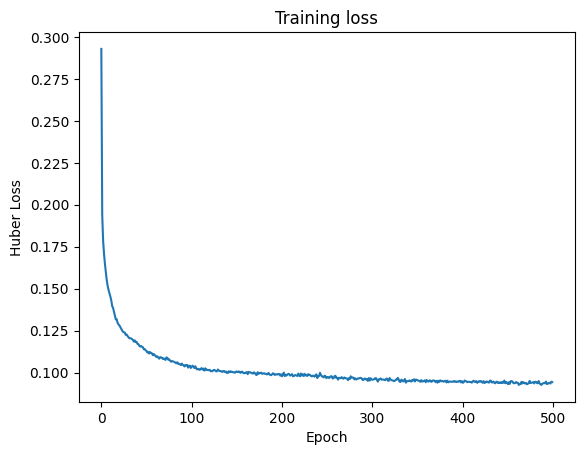


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [41]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space, bounded by tanh)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=500, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
encoder.save("saved_models/encoder_relu_tanh_btn.keras")

ae_columns = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_tanh_btn = pd.DataFrame(bottleneck, columns=ae_columns)
df_latent_ae_relu_tanh_btn = pd.concat([df_info_reset, df_ae_relu_tanh_btn], axis=1)

#### Testing Autoencoder

##### Similarity Functions

In [42]:
def find_similar_ae(player_name, player_season, latent_df, top_n=5, max_age=None, season_filter=None, same_position=False, same_league=False, same_preferred_foot=False):
    # Find player index by name and season
    mask_target = (
        (latent_df['player'].str.lower() == player_name.lower())
        & (latent_df['season'] == player_season)
    )
    player_idx = latent_df[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    real_player = latent_df.loc[idx, 'player']
    real_team = latent_df.loc[idx, 'team']
    season = latent_df.loc[idx, 'season']
    role = latent_df.loc[idx, 'pos']

    print(f"\n[AUTOENCODER] Searching similar players for: {real_player} ({real_team} - {season})")

    # Extract target player's 10 latent values
    player_vector = latent_df.loc[idx, ae_columns].values.reshape(1, -1)
    # Extract all players' latent values
    all_vectors = latent_df[ae_columns].values

    # Compute cosine similarity
    similarity = cosine_similarity(player_vector, all_vectors)[0]

    # Assign scores
    latent_df_temp = latent_df.copy()
    latent_df_temp['Similarity_Score'] = similarity

    # Exclude target player from results
    latent_df_temp = latent_df_temp.drop(index=idx)

    # Optional age filter
    if max_age is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['age'] <= max_age]

    # Optional season filter
    if season_filter is not None:
        latent_df_temp = latent_df_temp[latent_df_temp['season'] == season_filter]

    # Optional position filter
    if same_position:
        latent_df_temp = latent_df_temp[latent_df_temp['pos'] == role]

    # Optional league filter
    if same_league:
        latent_df_temp = latent_df_temp[latent_df_temp['league'] == latent_df.loc[idx, 'league']]

    # Optional preferred-foot filter
    if same_preferred_foot:
        latent_df_temp = latent_df_temp[latent_df_temp['preferred_foot'] == latent_df.loc[idx, 'preferred_foot']]

    latent_df_temp = latent_df_temp[latent_df_temp['player'] != player_name]

    # Sort from most similar to least similar
    similar_players = latent_df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()

    # Format score as a readable percentage
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    output_columns = ['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']
    return similar_players[output_columns]

In [43]:
def find_similar_ensemble(
    player_name,
    player_season,
    latent_df_a=df_latent_ae_relu_tanh_btn,
    latent_df_b=df_latent_ae_tanh_dropout,
    latent_df_c=df_latent_ae_tanh,
    top_n=5,
    max_age=None,
    season_filter=None,
    same_position=False,
    same_league=False
):
    # Target player
    mask_target = (
        (latent_df_a['player'].str.lower() == player_name.lower())
        & (latent_df_a['season'] == player_season)
    )
    player_idx = latent_df_a[mask_target].index

    if len(player_idx) == 0:
        return "Player not found in the database."

    idx = player_idx[0]
    real_player = latent_df_a.loc[idx, 'player']
    real_team = latent_df_a.loc[idx, 'team']
    season = latent_df_a.loc[idx, 'season']
    role = latent_df_a.loc[idx, 'pos']
    league = latent_df_a.loc[idx, 'league']

    print(f"\n[ENSEMBLE] Searching similar players for: {real_player} ({real_team} - {season})")

    # Average cosine similarity from the three latent spaces
    vector_a = latent_df_a.loc[idx, ae_columns].values.reshape(1, -1)
    vector_b = latent_df_b.loc[idx, ae_columns].values.reshape(1, -1)
    vector_c = latent_df_c.loc[idx, ae_columns].values.reshape(1, -1)
    sim_a = cosine_similarity(vector_a, latent_df_a[ae_columns].values)[0]
    sim_b = cosine_similarity(vector_b, latent_df_b[ae_columns].values)[0]
    sim_c = cosine_similarity(vector_c, latent_df_c[ae_columns].values)[0]
    sim_ensemble = (sim_a + sim_b + sim_c) / 3

    df_temp = latent_df_a.copy()
    df_temp['Similarity_Score'] = sim_ensemble
    df_temp = df_temp.drop(index=idx)

    if max_age is not None:
        df_temp = df_temp[df_temp['age'] <= max_age]

    if season_filter is not None:
        df_temp = df_temp[df_temp['season'] == season_filter]

    if same_position:
        df_temp = df_temp[df_temp['pos'] == role]

    if same_league:
        df_temp = df_temp[df_temp['league'] == league]

    df_temp = df_temp[df_temp['player'] != player_name]

    similar_players = df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()
    similar_players['Match %'] = (similar_players['Similarity_Score'] * 100).round(1).astype(str) + '%'

    return similar_players[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]

##### Testing

###### Single Testing

In [44]:
# ==========================================
# 5. TEST THE MODEL
# ==========================================
target_player = "Riccardo Orsolini"
target_season = "2024 - 2025"
max_age = None

models_to_test = {
    'Relu': df_latent_ae_relu,
    'Tanh': df_latent_ae_tanh,
    'Mix ReLU': df_latent_ae_mix_relu,
    'Mix Tanh': df_latent_ae_mix_tanh,
    'ReLU + Dropout': df_latent_ae_relu_dropout,
    'Tanh + Dropout': df_latent_ae_tanh_dropout,
    'ReLU + Tanh bottleneck': df_latent_ae_relu_tanh_btn,
}

for model_name, model_df in models_to_test.items():
    print(f"\n===== Model: {model_name} =====")
    ae_results = find_similar_ae(
        player_name=target_player,
        player_season=target_season,
        latent_df=model_df,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=True
    )
    display(ae_results)

print("\n===== Model: Ensemble =====")
ensemble_results = find_similar_ensemble(
    player_name=target_player,
    player_season=target_season,
    top_n=5,
    max_age=max_age,
    season_filter=None,
    same_position=True,
    same_league=False
)
display(ensemble_results)


===== Model: Relu =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
287,Julián Álvarez,24,Atlético Madrid,FW,ESP-La Liga,2024 - 2025,99.4%
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,99.2%
2556,Harry Kane,29,Tottenham,FW,ENG-Premier League,2022 - 2023,99.2%
1711,Alexandre Lacazette,32,Lyon,FW,FRA-Ligue 1,2023 - 2024,99.1%
2040,Serhou Guirassy,27,Stuttgart,FW,GER-Bundesliga,2023 - 2024,98.9%



===== Model: Tanh =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,87.9%
1063,Randal Kolo Muani,25,Juventus,FW,ITA-Serie A,2024 - 2025,84.8%
2835,Terem Moffi,23,Lorient,FW,FRA-Ligue 1,2022 - 2023,81.3%
1711,Alexandre Lacazette,32,Lyon,FW,FRA-Ligue 1,2023 - 2024,79.6%
365,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,79.0%



===== Model: Mix ReLU =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


...

,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,92.8%
365,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,90.2%
2977,Mergim Berisha,24,Augsburg,FW,GER-Bundesliga,2022 - 2023,88.1%
882,Andrej Ilic,24,Union Berlin,FW,GER-Bundesliga,2024 - 2025,87.4%
355,Cristhian Stuani,37,Girona,FW,ESP-La Liga,2024 - 2025,87.1%



===== Model: ReLU + Tanh bottleneck =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
752,Omar Marmoush,25,Eint Frankfurt,FW,GER-Bundesliga,2024 - 2025,87.3%
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,87.1%
287,Julián Álvarez,24,Atlético Madrid,FW,ESP-La Liga,2024 - 2025,80.9%
1479,Álex Berenguer,28,Athletic Club,FW,ESP-La Liga,2023 - 2024,80.5%
2088,Gianluca Scamacca,24,Atalanta,FW,ITA-Serie A,2023 - 2024,78.3%



===== Model: Ensemble =====

[ENSEMBLE] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,89.3%
365,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,82.1%
1479,Álex Berenguer,28,Athletic Club,FW,ESP-La Liga,2023 - 2024,81.5%
1711,Alexandre Lacazette,32,Lyon,FW,FRA-Ligue 1,2023 - 2024,79.8%
752,Omar Marmoush,25,Eint Frankfurt,FW,GER-Bundesliga,2024 - 2025,79.8%


###### Bulk Testing

In [45]:
# Single table with all results (target player x model)
target = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Andrea Pinamonti", 'Erling Haaland', "Xavi Simons", "Riccardo Orsolini"]
same_position = [False, False, False, False, False, False, False]
max_age = 23

target_same_position = dict(zip(target, same_position))
all_results = []

for player in target:
    for model_name, model_df in models_to_test.items():
        res = find_similar_ae(
            player_name=player,
            player_season=target_season,
            latent_df=model_df,
            top_n=5,
            max_age=max_age,
            season_filter=None,
            same_position=target_same_position[player],
            same_league=False,
            same_preferred_foot=False
        )

        if isinstance(res, pd.DataFrame):
            res = res.copy()
            res["target_player"] = player
            res["target_season"] = target_season
            res["model_used"] = model_name
            res["rank"] = range(1, len(res) + 1)
            all_results.append(res)

    # Add the ensemble result as well
    res_ensemble = find_similar_ensemble(
        player_name=player,
        player_season=target_season,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=target_same_position[player],
        same_league=False
    )

    if isinstance(res_ensemble, pd.DataFrame):
        res_ensemble = res_ensemble.copy()
        res_ensemble["target_player"] = player
        res_ensemble["target_season"] = target_season
        res_ensemble["model_used"] = "Ensemble"
        res_ensemble["rank"] = range(1, len(res_ensemble) + 1)
        all_results.append(res_ensemble)

# Final grouped DataFrame
grouped_results_table = pd.concat(all_results, ignore_index=True)

# Column order for readability
grouped_results_table = (
    grouped_results_table[
        ["target_player", "target_season", "model_used", "rank", "player", "age", "team", "pos", "league", "season", "Match %"]
    ]
    .sort_values(["target_player", "model_used", "rank"])
    .reset_index(drop=True)
)

display(grouped_results_table)


[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[ENSEMBLE] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 202

,target_player,target_season,model_used,rank,player,age,team,pos,league,season,Match %
0,Alessandro Bastoni,2024 - 2025,Ensemble,1,Jules Koundé,23,Barcelona,DF,ESP-La Liga,2022 - 2023,88.2%
1,Alessandro Bastoni,2024 - 2025,Ensemble,2,Facundo Medina,23,Lens,DF,FRA-Ligue 1,2022 - 2023,82.7%
2,Alessandro Bastoni,2024 - 2025,Ensemble,3,Riccardo Calafiori,21,Bologna,DF,ITA-Serie A,2023 - 2024,81.6%
3,Alessandro Bastoni,2024 - 2025,Ensemble,4,Angelo Stiller,23,Stuttgart,MF,GER-Bundesliga,2024 - 2025,80.8%
4,Alessandro Bastoni,2024 - 2025,Ensemble,5,Miguel Gutiérrez,22,Girona,DF,ESP-La Liga,2023 - 2024,79.7%
...,...,...,...,...,...,...,...,...,...,...,...
275,Xavi Simons,2024 - 2025,Tanh + Dropout,1,Phil Foden,22,Manchester City,FW,ENG-Premier League,2022 - 2023,90.7%
276,Xavi Simons,2024 - 2025,Tanh + Dropout,2,Matìas Soulé,21,Roma,"MF,DF",ITA-Serie A,2024 - 2025,85.6%
277,Xavi Simons,2024 - 2025,Tanh + Dropout,3,Callum Hudson-Odoi,22,Nott'ham Forest,"FW,MF",ENG-Premier League,2023 - 2024,83.4%
278,Xavi Simons,2024 - 2025,Tanh + Dropout,4,Tetê,22,Lyon,"FW,MF",FRA-Ligue 1,2022 - 2023,83.0%


In [46]:
grouped_results_table.to_csv("grouped_results_table.csv", index=False)

#### Choice explanation

To maximize accuracy and handle tactical nuances such as hybrid roles and statistical outliers, the final pipeline uses an ensemble of two autoencoders and averages their cosine similarity scores.

* Model A: the specialist (ReLU encoder with tanh bottleneck)
    * Architecture: Standard

            Input -> 64 -> Dropout -> 32 -> 10 -> 32 -> 64 -> Dropout -> Output.

    * Encoder activation: ReLU. This can create sparse intermediate representations and keep the model focused on the strongest signals.
    * Bottleneck activation: tanh. This constrains the 10D latent space to [-1, 1], which is compatible with cosine similarity.
    * Epochs & batch size: 500 epochs, batch size 32.

* Model B: the holistic model (tanh network with dropout)
    * Architecture: Deeper layers to capture highly non-linear and complex tactical relationships.

            Input -> 128 -> Dropout -> 64 -> 32 -> 10 -> 32 -> 64 -> Dropout -> 128 -> Output

    * Activation: tanh throughout. This keeps the latent space bounded and preserves sign information in the compressed representation.
    * Epochs & batch size: 500 epochs, batch size 32.

* Model C: the balancer (tanh pure)
    * Architecture: Standard

            Input -> 64 -> 32 -> 10 -> 32 -> 64 -> Output.

    * Activation: tanh throughout. This ensures all neurons remain active, providing a stable, bounded mapping of the data without induced sparsity.
    * Rationale: A clean, holistic baseline with no dropout. It reads the player's entire statistical profile symmetrically, acting as the stabilizing "judge" to ground the results when the first two specialized models disagree heavily.
    * Epochs & batch size: 300 epochs, batch size 32.

* Training hyperparameters (both models)
    * Loss function: Huber. A robust regression loss that is less sensitive to outliers than plain MSE.
    * Optimizer: Adam.

* Ensemble strategy
    * Implementation: Ensemble_Score = (Score_Model_A + Score_Model_B + Score_Model_C) / 3

    * Rationale: 
        * Model A is highly precise but can be rigid; 
        * Model B is tactically creative but can occasionally drift; 
        * Model C provides a stable baseline. 
        
        Averaging their raw Cosine Similarity scores stabilizes the final output. It boosts players recognized by all three architectures while heavily penalizing "hallucinations" (e.g., when a single model confuses a high-scoring winger with a pure striker).

* **NEXT STEP:**
Add spatial/GPS tracking data (e.g., heatmaps, average pitch positions, distance covered) to better contextualize on-ball events and definitively separate players with similar stats but different positional roles on the pitch.

#### Save csv models

In [47]:
print("--- Final extraction and saving of vector databases ---")

# Latent column names (the 10 dimensions)
ae_columns = [f'AE_{i+1}' for i in range(10)]

# 1. Model A (Specialist: ReLU + Tanh Bottleneck)
# Use the latent dataframes already in memory after training
# Assume df_latent_ae_relu_tanh_btn has been created in this notebook
print("Saving Model A...")
df_latent_ae_relu_tanh_btn.to_csv('saved_models/database_dna_a.csv', index=False)

# 2. Model B (Explorer: Tanh + Dropout)
print("Saving Model B...")
df_latent_ae_tanh_dropout.to_csv('saved_models/database_dna_b.csv', index=False)

# 3. Model C (Balancer: Pure Tanh)
print("Saving Model C...")
df_latent_ae_tanh.to_csv('saved_models/database_dna_c.csv', index=False)

print("CSV files generated successfully. Ready to be loaded in the web app or used for clustering.")

--- Final extraction and saving of vector databases ---
Saving Model A...
Saving Model B...
Saving Model C...
CSV files generated successfully. Ready to be loaded in the web app or used for clustering.


## Anomaly Detection

### Remap of Roles

In [48]:
pos_mapping = {
    "MF,FW": "OM",
    "MF,DF": "MF",
    "FW,MF": "OW",
    "FW,DF": "OW",
    "DF,MF": "FB",
    "DF,FW": "FB",
}

df["pos"] = df["pos"].replace(pos_mapping)

if "df_info" in globals():
    df_info["pos"] = df_info["pos"].replace(pos_mapping)

if "df_info_reset" in globals():
    df_info_reset["pos"] = df_info_reset["pos"].replace(pos_mapping)

### SVM

In [49]:
role_target = "OM"
df_info_base = df_info_reset.copy() if "df_info_reset" in globals() else df_info.copy()

if "pos" not in df_info_base.columns:
    raise KeyError("Column 'pos' not found in the info dataframe.")

mask_role_svm = df_info_base["pos"].fillna("").str.contains(role_target, regex=False)
df_role_svm = df_info_base.loc[mask_role_svm].copy()
X_role_svm_scaled = X_scaled[mask_role_svm.values]

if len(df_role_svm) < 10:
    raise ValueError(f"Too few players for role {role_target}: {len(df_role_svm)}")

# 2) Anomaly Detection (One-Class SVM)
from sklearn.svm import OneClassSVM
svm_one_class = OneClassSVM(nu=0.05, kernel="rbf", gamma="scale")

# 3) Training and Assignment on ORIGINAL SCALED data (no PCA)
df_role_svm["Anomaly_SVM"] = svm_one_class.fit_predict(X_role_svm_scaled)

# 4) Output and Analysis
print("Count of normal players (1) and anomalies (-1):")
print(df_role_svm["Anomaly_SVM"].value_counts().sort_index())

required_cols = ["player", "team", "age", "pos", "Anomaly_SVM"]
missing_cols = [c for c in required_cols if c not in df_role_svm.columns]
if missing_cols:
    raise KeyError(f"Missing columns for anomaly output: {missing_cols}")

aliens_svm = df_role_svm[df_role_svm["Anomaly_SVM"] == -1].copy()
display(aliens_svm[["player", "team", "age", "pos", "Anomaly_SVM"]].head(10))

Count of normal players (1) and anomalies (-1):
Anomaly_SVM
-1     23
 1    261
Name: count, dtype: int64


,player,team,age,pos,Anomaly_SVM
46,Mikkel Damsgaard,Brentford,24,OM,-1
204,Nicolás Domínguez,Nott'ham Forest,26,OM,-1
248,Lucas Paquetá,West Ham,26,OM,-1
260,Matheus Cunha,Wolves,25,OM,-1
428,Takefusa Kubo,Real Sociedad,23,OM,-1
617,Sofiane Diop,Nice,24,OM,-1
749,Mario Götze,Eint Frankfurt,32,OM,-1
922,Ademola Lookman,Atalanta,26,OM,-1
960,Mattia Felici,Cagliari,23,OM,-1
1071,Fisayo Dele-Bashiru,Lazio,23,OM,-1


### Tactical Profiling: Finding Hybrid and Mislabelled Roles with the KNN Classifier

Instead of using KNN to classify new data, we use its *classification errors* on the training set (through cross-validation) as a scouting tool.
If KNN looks at a defender's data and says "For me this is a midfielder", we have just found a player who breaks the patterns of the official role and behaves like a playmaker or ball-progressor.

In [50]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict

def tactical_profiling_knn(df_info_input, X_scaled_input, macro_role="DF", n_neighbors=5, weights="distance", cv=5, top_n=15):
    """
    Learn role patterns with KNN and print the players whose predicted role differs
    from the selected macro role.
    """
    df_knn = df_info_input.copy()

    if "pos" not in df_knn.columns:
        raise KeyError("Column 'pos' not found in the info dataframe.")

    # Keep the current Macro_Role computation unchanged
    df_knn["Macro_Role"] = df_knn["pos"]

    valid_mask = df_knn["Macro_Role"].notna() & (df_knn["Macro_Role"] != "")
    df_knn = df_knn.loc[valid_mask].copy()
    X_knn = X_scaled_input[valid_mask.values]

    knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)
    df_knn["Predicted_Role"] = cross_val_predict(
        knn,
        X_knn,
        df_knn["Macro_Role"],
        cv=cv
    )

    hybrid_profiles = df_knn[df_knn["Macro_Role"] != df_knn["Predicted_Role"]].copy()

    print("Confusion table (true role vs predicted role):")
    role_confusion = pd.crosstab(
        df_knn["Macro_Role"],
        df_knn["Predicted_Role"],
        rownames=["Macro_Role"],
        colnames=["Predicted_Role"]
    )
    display(role_confusion)

    mismatched_role = hybrid_profiles[hybrid_profiles["Macro_Role"] == macro_role].copy()

    print(f"\nPlayers with Macro_Role = {macro_role} and a different predicted role:")
    if mismatched_role.empty:
        print(f"No mismatched players found for role {macro_role}.")
    else:
        display(mismatched_role[["player", "team", "age", "Macro_Role", "Predicted_Role"]].head(top_n))

    return {
        "df_knn": df_knn,
        "hybrid_profiles": hybrid_profiles,
        "role_confusion": role_confusion,
        "mismatched_role": mismatched_role
    }


# Example usage
knn_results = tactical_profiling_knn(
    df_info_input=df_info_reset if "df_info_reset" in globals() else df_info,
    X_scaled_input=X_scaled,
    macro_role="FB",
    top_n=100
 )

Confusion table (true role vs predicted role):


Predicted_Role,DF,FB,FW,MF,OM,OW
Macro_Role,,,,,,
DF,1062,37,1,65,4,5
FB,119,18,1,36,9,7
FW,0,0,345,6,26,86
MF,53,12,5,731,51,23
OM,3,3,31,89,79,79
OW,4,3,114,29,81,179



Players with Macro_Role = FB and a different predicted role:


,player,team,age,Macro_Role,Predicted_Role
42,Keane Lewis-Potter,Brentford,23,FB,DF
61,Mats Wieffer,Brighton,24,FB,MF
78,Reece James,Chelsea,24,FB,DF
124,Ben Johnson,Ipswich Town,24,FB,DF
165,Matheus Nunes,Manchester City,25,FB,DF
...,...,...,...,...,...
1879,Maximilian Wittek,Bochum,27,FB,MF
1887,Fabian Nürnberger,Darmstadt 98,24,FB,DF
1889,Klaus Gjasula,Darmstadt 98,33,FB,DF
1894,Matthias Bader,Darmstadt 98,26,FB,MF


### Autoencoder Reconstruction Error

## End

In [51]:
end_time = time.time()

In [52]:

elapsed_time = end_time - start_time
elapsed_minutes = round(elapsed_time / 60)
remaining_seconds = round(elapsed_time % 60)
print(f"\nTotal execution time: {elapsed_minutes:.0f}.{remaining_seconds:.0f} min")


Total execution time: 30.16 min
